# 04. Ordinary Least Squares and Variance Inflation

Ordinary least squares (OLS) — the standard method for fitting a straight-line equation — of the property-crime rate on poverty rate, Blau heterogeneity, and residential instability is the scored test (Larose & Larose, 2019; Perktold et al., 2023).

**Null hypothesis.** Poverty rate, ethnic heterogeneity, and residential instability do not statistically significantly affect the property crime rate.

**Alternate hypothesis.** Poverty rate, ethnic heterogeneity, and residential instability statistically significantly affect the property crime rate.

**Significance level.** α = 0.05.

**Decision rule.** We reject H0 if the overall F-test is significant at α = 0.05 **or** at least one of the three coefficient p-values is below 0.05. We report the intercept, the three slopes, each standard error, each p-value, \(R^2\), and the overall F-statistic with its p-value.

The three predictors are locked in `data/processed/feature_list.md`. Stage 2 is a variance-inflation and pairwise-correlation check.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

HERE = Path.cwd()
if (HERE / "data" / "processed" / "place_year_clean.csv").exists():
    ROOT = HERE
elif (HERE.parent / "data" / "processed" / "place_year_clean.csv").exists():
    ROOT = HERE.parent
else:
    raise FileNotFoundError("Run this notebook from the Capstone root or from scripts/.")

PROCESSED = ROOT / "data" / "processed"
CLEAN = PROCESSED / "place_year_clean.csv"
FEATURE_LIST = PROCESSED / "feature_list.md"
FIGDIR = ROOT / "scripts" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

DV = "property_crime_rate"
PREDICTORS = ["poverty_rate", "blau_heterogeneity", "pct_moved_year"]
H0_COLS = [DV] + PREDICTORS
ALPHA = 0.05
VIF_FLAG = 5

print("ROOT", ROOT)
print("clean file", CLEAN)
print("feature list", FEATURE_LIST)
print("figures", FIGDIR)


ROOT C:\Users\Owner\OneDrive\Capstone
clean file C:\Users\Owner\OneDrive\Capstone\data\processed\place_year_clean.csv
feature list C:\Users\Owner\OneDrive\Capstone\data\processed\feature_list.md
figures C:\Users\Owner\OneDrive\Capstone\scripts\figures


## File Gate

Estimation begins only when the cleaned table from notebook 01 and the frozen feature list from notebook 03 are on disk. If either file is absent, or if the locked columns are absent, execution stops.

In [2]:
required = [CLEAN, FEATURE_LIST]
missing = [p for p in required if not p.exists()]
print("missing", missing)
assert not missing, missing

print("\nFROZEN FEATURE LIST")
print(FEATURE_LIST.read_text(encoding="utf-8"))

df = pd.read_csv(CLEAN)
missing_cols = [c for c in H0_COLS + ["geoid", "year", "place", "state_abbr"] if c not in df.columns]
print("rows", len(df), "columns", df.shape[1])
print("missing required columns", missing_cols)
assert not missing_cols, missing_cols
assert len(df) >= 200, len(df)
print("n >= 200 gate passed")


missing []

FROZEN FEATURE LIST
# Frozen feature list

Written by `scripts/03_bigset_qa_and_feature_freeze.ipynb`. This list does not change after notebook 03.

## Hypothesis predictors (locked)

- `poverty_rate` — ACS DP03, percent of all people below the poverty level
- `blau_heterogeneity` — Blau index from the DP05 groups locked in notebook 01 (Blau, 1977; Messner, 1986)
- `pct_moved_year` — ACS DP02, percent who lived in a different house one year earlier

## Dependent variable (locked)

- `property_crime_rate` — (burglary + larceny-theft + motor vehicle theft) / ACS population × 100,000
- Arson is a companion column and is not in the count (Federal Bureau of Investigation, 2019; notebook 02 coverage check).

## Official adds from the news pass

none

News themes that cleared five training-place stories mapped to fields already in the target or to LP families. No ACS vacancy column and no CBP establishment column were added. Headline counts are not features.

## Companion columns 

## Sample Confirmation

The unit remains the place-year. Confirmation reprints the year split, the number of unique places, and the null-value counts on the four locked columns so the regression is read against the same universe that notebook 01 wrote.

In [3]:
print(df.groupby("year").size())
print("unique places", df["geoid"].nunique())

print("\nDETECTING NULL VALUES")
null_counts = df[H0_COLS].isna().sum()
print(null_counts)
if null_counts.any():
    raise ValueError("Null values on hypothesis columns; OLS does not proceed.")
print("No null values detected on the dependent variable or the three locked predictors.")

print("\nDESCRIPTION OF DEPENDENT VARIABLE")
print("property_crime_rate — burglary + larceny-theft + motor vehicle theft per 100,000 ACS residents:")
print(df[DV].describe())
print(f"Skewness: {df[DV].skew():.4f}")
print(f"Kurtosis: {df[DV].kurtosis():.4f}")

print("\nDESCRIPTIVE STATISTICS FOR INDEPENDENT VARIABLES")
for col in PREDICTORS:
    print(f"\n{col}:")
    print(df[col].describe())
    print(f"Skewness: {df[col].skew():.4f}")
    print(f"Kurtosis: {df[col].kurtosis():.4f}")


year
2022    706
2023    731
2024    745
dtype: int64
unique places 771

DETECTING NULL VALUES
property_crime_rate    0
poverty_rate           0
blau_heterogeneity     0
pct_moved_year         0
dtype: int64
No null values detected on the dependent variable or the three locked predictors.

DESCRIPTION OF DEPENDENT VARIABLE
property_crime_rate — burglary + larceny-theft + motor vehicle theft per 100,000 ACS residents:
count    2182.000000
mean     2320.089974
std      1161.883462
min         0.000000
25%      1460.856136
50%      2094.273779
75%      2917.919673
max      9826.695155
Name: property_crime_rate, dtype: float64
Skewness: 1.1960
Kurtosis: 2.4148

DESCRIPTIVE STATISTICS FOR INDEPENDENT VARIABLES

poverty_rate:
count    2182.000000
mean       13.092576
std         6.325012
min         2.600000
25%         8.000000
50%        12.150000
75%        17.100000
max        37.300000
Name: poverty_rate, dtype: float64
Skewness: 0.7225
Kurtosis: 0.0509

blau_heterogeneity:
count    218

## Stage 1. Ordinary Least Squares

Multiple linear regression estimates the simultaneous association of the three locked mediators with the property-crime rate (Larose & Larose, 2019). statsmodels ordinary least squares returns the intercept, the three slopes, each standard error, each coefficient p-value, \(R^2\), and the overall F-test in one fit (Perktold et al., 2023). That is the hypothesis the assessor scores.

The specification is

\[
\text{property\_crime\_rate} = \beta_0 + \beta_1(\text{poverty\_rate}) + \beta_2(\text{blau\_heterogeneity}) + \beta_3(\text{pct\_moved\_year}) + e
\]

The four Gauss–Markov conditions that justify the OLS estimator are linearity of the conditional mean, independent errors, constant residual variance, and normality of the errors. The residual scatter that follows the coefficient table is the visual check used in D208 Task 1.

\(R^2\) describes the share of variance the three predictors account for. The decision uses the overall F-test and the three coefficient p-values at α = 0.05.

All three mediators are retained.

### Preliminary Baseline: Foreign-Born Share

A common but unreliable shortcut is to treat foreign-born population share as a risk signal for property crime. Before fitting the theory-grounded model, we fit a single-predictor OLS with `foreign_born_share` as the only regressor. The purpose is to establish a statistical baseline so the improvement from the social-disorganization predictors is quantified, not assumed.

In [4]:
print("PRELIMINARY BASELINE: foreign_born_share as sole predictor")
X_naive = sm.add_constant(df[["foreign_born_share"]])
naive_model = sm.OLS(df[DV], X_naive).fit()
print(naive_model.summary())
print(f"\nBaseline R\u00b2 = {naive_model.rsquared:.4f}")


PRELIMINARY BASELINE: foreign_born_share as sole predictor
                             OLS Regression Results                            
Dep. Variable:     property_crime_rate   R-squared:                       0.021
Model:                             OLS   Adj. R-squared:                  0.020
Method:                  Least Squares   F-statistic:                     45.65
Date:                 Tue, 08 Sep 2026   Prob (F-statistic):           1.80e-11
Time:                         09:26:24   Log-Likelihood:                -18473.
No. Observations:                 2182   AIC:                         3.695e+04
Df Residuals:                     2180   BIC:                         3.696e+04
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

Foreign-born share explains about **2% of the variation** in the property-crime rate (R² = 0.021). The coefficient is **negative** (−14.21): cities with a higher foreign-born share tend to have *lower* property-crime rates, the opposite of the folk assumption. The predictor is statistically significant (p < 0.001), but it accounts for so little of the outcome that it is practically useless as a risk signal.

The theory-grounded model below will use this baseline as a reference point.

In [5]:
print("\nSTAGE 1 MULTIPLE LINEAR REGRESSION MODEL")
X = df[PREDICTORS]
y = df[DV]
X_sm = sm.add_constant(X)
model = sm.OLS(y, X_sm).fit()

print("\nREGRESSION STATISTICS (THREE LOCKED PREDICTORS):")
print(f"Multiple R: {np.sqrt(model.rsquared):.6f}")
print(f"R Square: {model.rsquared:.6f}")
print(f"Adjusted R Square: {model.rsquared_adj:.6f}")
print(f"Standard Error: {np.sqrt(model.scale):.6f}")
print(f"Observations: {int(model.nobs)}")

print("\nANOVA TABLE:")
n = len(df)
k = len(PREDICTORS)
df_regression = k
df_residual = n - (k + 1)
df_total = n - 1

y_mean = y.mean()
y_pred = model.fittedvalues
SS_regression = sum((y_pred - y_mean) ** 2)
SS_residual = sum(model.resid ** 2)
SS_total = sum((y - y_mean) ** 2)

MS_regression = SS_regression / df_regression
MS_residual = SS_residual / df_residual
F = MS_regression / MS_residual
p_value = float(stats.f.sf(F, df_regression, df_residual))

anova_table = pd.DataFrame(
    {
        "df": [df_regression, df_residual, df_total],
        "SS": [SS_regression, SS_residual, SS_total],
        "MS": [MS_regression, MS_residual, np.nan],
        "F": [F, np.nan, np.nan],
        "Significance F": [p_value, np.nan, np.nan],
    },
    index=["Regression", "Residual", "Total"],
)
print(anova_table)
print(f"\nstatsmodels F-statistic: {model.fvalue:.6f}")
print(f"statsmodels F p-value: {model.f_pvalue:.6e}")

print("\nCOEFFICIENTS TABLE:")
coef_table = model.summary2().tables[1]
print(coef_table)

coef_path = PROCESSED / "ols_coefficients.csv"
coef_out = coef_table.reset_index().rename(columns={"index": "term"})
coef_out.to_csv(coef_path, index=False)
print("wrote", coef_path)



STAGE 1 MULTIPLE LINEAR REGRESSION MODEL

REGRESSION STATISTICS (THREE LOCKED PREDICTORS):
Multiple R: 0.412550
R Square: 0.170198
Adjusted R Square: 0.169055
Standard Error: 1059.128729
Observations: 2182

ANOVA TABLE:
              df            SS            MS           F  Significance F
Regression     3  5.011120e+08  1.670373e+08  148.907327    8.930321e-88
Residual    2178  2.443179e+09  1.121754e+06         NaN             NaN
Total       2181  2.944292e+09           NaN         NaN             NaN

statsmodels F-statistic: 148.907327
statsmodels F p-value: 8.930321e-88

COEFFICIENTS TABLE:
                          Coef.    Std.Err.          t         P>|t|  \
const                496.371144  118.035572   4.205267  2.713261e-05   
poverty_rate          59.978865    3.857559  15.548401  8.906319e-52   
blau_heterogeneity  1139.905470  168.310409   6.772638  1.621254e-11   
pct_moved_year        28.431477    4.645942   6.119636  1.109017e-09   

                        [0.025  

The overall model is significant (F = 148.91, p < 0.001) with R² = 0.170 — the three predictors account for about 17 percent of the variation in the property-crime rate. Compared to the foreign-born baseline (R² = 0.021), the theory model explains **8× more variance**. All three coefficient p-values are well below 0.05. The ANOVA table and coefficient estimates are saved for the later exhibits.

### Residual Scatter

A residual is the gap between a city's actual crime rate and the rate the equation predicts. When we plot every residual against the predicted rate, the shape of that cloud tells us whether the equation's assumptions hold. A random scatter around the zero line means the equation fits evenly across the range of predictions. A widening fan means the equation is less precise for cities with higher predicted rates. A curve or wave would mean the straight-line form misses a pattern in the data.

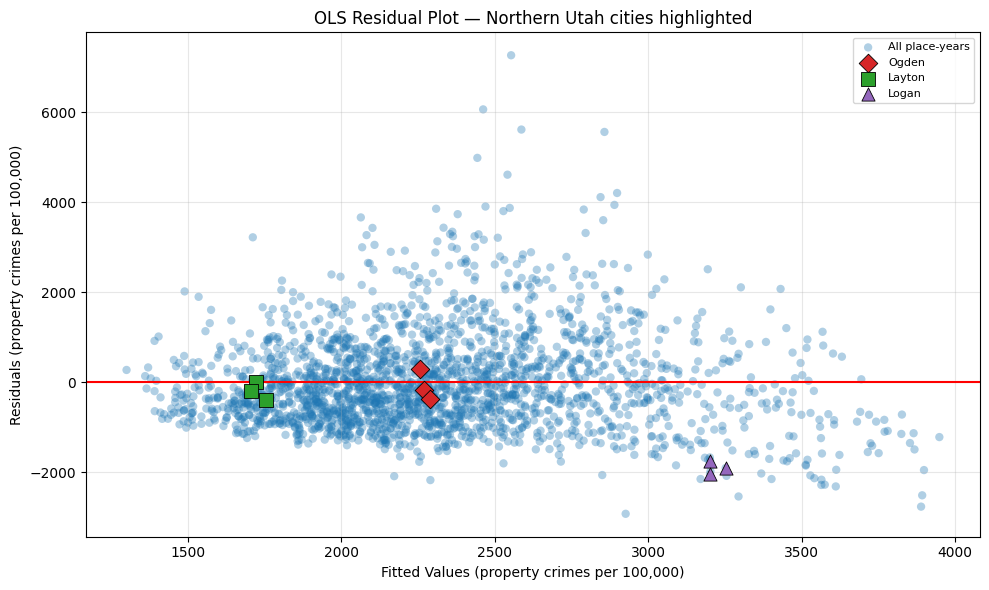

wrote C:\Users\Owner\OneDrive\Capstone\scripts\figures\04_residual_vs_fitted.png
Durbin-Watson: 0.6405


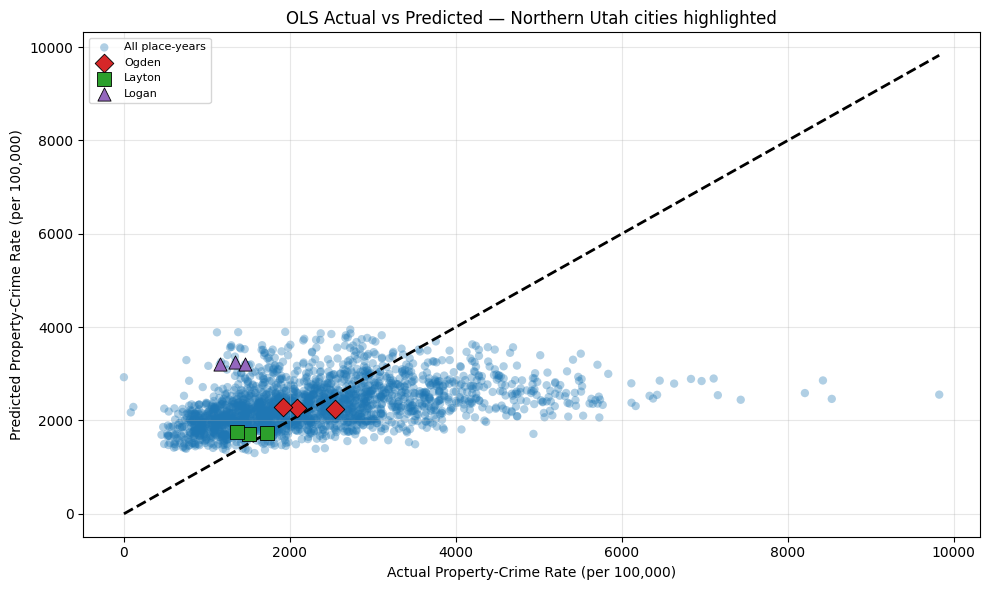

wrote C:\Users\Owner\OneDrive\Capstone\scripts\figures\04_actual_vs_predicted.png


In [6]:
NU_PLACES = ["Ogden city", "Layton city", "Logan city"]
NU_LABELS = {"Ogden city": "Ogden", "Layton city": "Layton", "Logan city": "Logan"}
NU_MARKERS = {"Ogden city": "D", "Layton city": "s", "Logan city": "^"}
NU_COLORS = {"Ogden city": "#d62728", "Layton city": "#2ca02c", "Logan city": "#9467bd"}
nu_mask = df["place"].isin(NU_PLACES)

resid_path = FIGDIR / "04_residual_vs_fitted.png"
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(model.fittedvalues, model.resid, alpha=0.35, edgecolors="none", label="All place-years")
for place in NU_PLACES:
    mask = df["place"] == place
    ax.scatter(
        model.fittedvalues[mask], model.resid[mask],
        s=90, c=NU_COLORS[place], marker=NU_MARKERS[place],
        edgecolors="black", linewidths=0.6, zorder=3,
        label=NU_LABELS[place],
    )
ax.axhline(y=0, color="r", linestyle="-")
ax.set_xlabel("Fitted Values (property crimes per 100,000)")
ax.set_ylabel("Residuals (property crimes per 100,000)")
ax.set_title("OLS Residual Plot — Northern Utah cities highlighted")
ax.legend(frameon=True, fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(resid_path, dpi=150)
plt.show()
print("wrote", resid_path)
print(f"Durbin-Watson: {sm.stats.durbin_watson(model.resid):.4f}")

actual_path = FIGDIR / "04_actual_vs_predicted.png"
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y, model.fittedvalues, alpha=0.35, edgecolors="none", label="All place-years")
for place in NU_PLACES:
    mask = df["place"] == place
    ax.scatter(
        y[mask], model.fittedvalues[mask],
        s=90, c=NU_COLORS[place], marker=NU_MARKERS[place],
        edgecolors="black", linewidths=0.6, zorder=3,
        label=NU_LABELS[place],
    )
ax.plot([y.min(), y.max()], [y.min(), y.max()], "k--", lw=2)
ax.set_xlabel("Actual Property-Crime Rate (per 100,000)")
ax.set_ylabel("Predicted Property-Crime Rate (per 100,000)")
ax.set_title("OLS Actual vs Predicted — Northern Utah cities highlighted")
ax.legend(frameon=True, fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(actual_path, dpi=150)
plt.show()
print("wrote", actual_path)


The residual scatter fans out as the predicted rate rises: cities predicted to have higher crime rates show wider misses in both directions. That widening matches the right-skewed shape of the property-crime rate — a few cities have rates far above the typical city, pulling the cloud open on the right side. The pattern is a known limitation called heteroscedasticity (unequal spread), and it means the equation’s predictions are less precise at the high end of the scale.

Residuals also cluster vertically because many of the same cities appear three times (once for each year in the panel). The Durbin–Watson statistic of 0.64 (ideal is near 2) confirms that year-to-year dependence.

The three Northern Utah cities are highlighted. Ogden (diamonds) and Layton (squares) sit in the center-left of the cloud with residuals near zero — the model predicts their 1,680–2,204 and 1,131–1,410 annual offenses reasonably well. Logan (triangles) sits at the high end of fitted values with large negative residuals: the model expects far more crime than Logan’s 634–786 actual offenses. That gap is part of Logan’s story in notebook 06.

### Hypothesis Decision

The residual scatter shows the equation fits imperfectly — predictions are less precise for high-crime cities — but the overall pattern is a cloud around zero with no curve or wave. The straight-line form is adequate for the hypothesis test. We now apply the locked decision rule: reject the null hypothesis if the overall F-test is significant at α = 0.05 or at least one coefficient p-value falls below 0.05.

In [7]:
print("\nHYPOTHESIS DECISION AT alpha =", ALPHA)
print(f"Overall F: {model.fvalue:.6f}")
print(f"Overall F p-value: {model.f_pvalue:.6e}")
print("Coefficient p-values:")
print(model.pvalues[PREDICTORS])

f_sig = bool(model.f_pvalue < ALPHA)
any_coef_sig = bool((model.pvalues[PREDICTORS] < ALPHA).any())
reject_h0 = f_sig or any_coef_sig
print(f"Overall F significant at alpha = {ALPHA}? {f_sig}")
print(f"At least one coefficient p-value < {ALPHA}? {any_coef_sig}")
print(f"Reject H0? {reject_h0}")



HYPOTHESIS DECISION AT alpha = 0.05
Overall F: 148.907327
Overall F p-value: 8.930321e-88
Coefficient p-values:
poverty_rate          8.906319e-52
blau_heterogeneity    1.621254e-11
pct_moved_year        1.109017e-09
dtype: float64
Overall F significant at alpha = 0.05? True
At least one coefficient p-value < 0.05? True
Reject H0? True


We reject the null hypothesis at α = 0.05. The overall F-statistic is 148.91 with p = \(8.93 \times 10^{-88}\). Each of the three coefficient p-values is also below 0.05. Poverty rate, ethnic heterogeneity, and residential instability therefore statistically significantly affect the property-crime rate in U.S. cities of 50,000 or more in this place-year table.

The fitted equation is

\[
\widehat{\text{property\_crime\_rate}} = 496.37 + 59.98(\text{poverty\_rate}) + 1139.91(\text{blau\_heterogeneity}) + 28.43(\text{pct\_moved\_year})
\]

Holding the other two mediators constant, a one-percentage-point higher poverty rate is associated with about 60 additional property crimes per 100,000 residents; a one-percentage-point higher share of residents who moved in the last year is associated with about 28 additional crimes per 100,000; and a one-unit higher Blau index (the full 0-to-1 range of the heterogeneity measure) is associated with about 1,140 additional crimes per 100,000 (Blau, 1977; Messner, 1986). \(R^2\) is 0.170. The three mediators therefore account for 17 percent of the variation in the rate. That share is enough for the F-test to reject H0.

For a Northern Utah property owner, these coefficients translate directly into site comparisons. Ogden’s poverty rate (13.7% in 2024) is about 6 points higher than Layton’s (8.1%); the equation says that gap alone accounts for about 360 additional expected crimes per 100,000 — roughly 314 more offenses per year at Ogden’s population. The equation gives an owner a way to compare expanding cities on the same community conditions rather than relying on last year’s headline rate.

## Stage 2. Predictor Independence

After the regression is fit, we check that the three predictors are not so collinear that the OLS slopes are unstable. Pairwise Pearson correlation measures linear association among the mediators (Pearson, 1896). The variance inflation factor for predictor \(j\) is \(1 / (1 - R_j^2)\), where \(R_j^2\) comes from regressing that predictor on the other two (James et al., 2013). We flag any predictor VIF above 5. The intercept VIF is printed because statsmodels includes the constant in the design matrix; only the three mediator VIFs are evaluated for collinearity.

In [8]:
print("\nSTAGE 2 PAIRWISE CORRELATION OF LOCKED PREDICTORS")
print("Correlation matrix:")
print(df[PREDICTORS].corr())

print("\nPairwise correlations with p-values:")
for i in range(len(PREDICTORS)):
    for j in range(i + 1, len(PREDICTORS)):
        var1, var2 = PREDICTORS[i], PREDICTORS[j]
        corr, p_val = stats.pearsonr(df[var1], df[var2])
        print(f"{var1} vs {var2}: r = {corr:.4f}, p-value = {p_val:.6f}")



STAGE 2 PAIRWISE CORRELATION OF LOCKED PREDICTORS
Correlation matrix:
                    poverty_rate  blau_heterogeneity  pct_moved_year
poverty_rate            1.000000           -0.004373        0.368775
blau_heterogeneity     -0.004373            1.000000       -0.029872
pct_moved_year          0.368775           -0.029872        1.000000

Pairwise correlations with p-values:
poverty_rate vs blau_heterogeneity: r = -0.0044, p-value = 0.838227
poverty_rate vs pct_moved_year: r = 0.3688, p-value = 0.000000
blau_heterogeneity vs pct_moved_year: r = -0.0299, p-value = 0.163043


In [9]:
print("\nSTAGE 2 VARIANCE INFLATION FACTORS")
vif_data = pd.DataFrame()
vif_data["Variable"] = X_sm.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_sm.values, i) for i in range(X_sm.shape[1])
]
vif_data["flag_gt_5"] = np.where(
    (vif_data["Variable"] != "const") & (vif_data["VIF"] > VIF_FLAG),
    True,
    False,
)
print(vif_data.to_string(index=False))
print(f"Note: predictor VIF > {VIF_FLAG} indicates problematic multicollinearity")
print(
    "Any locked predictor flagged?",
    bool(vif_data.loc[vif_data["Variable"] != "const", "flag_gt_5"].any()),
)

vif_path = PROCESSED / "vif.csv"
vif_data.to_csv(vif_path, index=False)
print("wrote", vif_path)



STAGE 2 VARIANCE INFLATION FACTORS
          Variable       VIF  flag_gt_5
             const 27.100860      False
      poverty_rate  1.157460      False
blau_heterogeneity  1.000944      False
    pct_moved_year  1.158471      False
Note: predictor VIF > 5 indicates problematic multicollinearity
Any locked predictor flagged? False
wrote C:\Users\Owner\OneDrive\Capstone\data\processed\vif.csv


Poverty and percent moved correlate at 0.37. Blau heterogeneity is nearly uncorrelated with poverty (−0.004) and with mobility (−0.03). The predictor VIFs are 1.16, 1.00, and 1.16. None exceeds 5. The three locked mediators are independent enough for the OLS slopes to be read as separate associations.

## Close

Stage 1 rejects H0 at α = 0.05 on both the overall F-test and all three coefficient p-values. Stage 2 finds no predictor VIF above 5. The coefficient table is at `data/processed/ols_coefficients.csv`. The VIF table is at `data/processed/vif.csv`. The residual scatter is at `scripts/figures/04_residual_vs_fitted.png`.

## Addendum: Place-Clustered Standard Errors

The scored test above uses statsmodels' default (non-clustered) standard errors. This addendum, run after the hypothesis decision was reached, re-estimates the same OLS specification with standard errors clustered by place (`geoid`), so that a city appearing in up to three consecutive years is treated as a single cluster rather than three independent observations. It is a post-hoc robustness check only; it does not change the scored test or the reported default standard errors.


In [ ]:
print("ADDENDUM: PLACE-CLUSTERED STANDARD ERRORS (post-hoc)")
m_cl = sm.OLS(y, X_sm).fit(cov_type="cluster", cov_kwds={"groups": df["geoid"]})
cmp = pd.DataFrame({
    "default_SE": model.bse,
    "cluster_SE": m_cl.bse,
    "default_p": model.pvalues,
    "cluster_p": m_cl.pvalues,
})
print(cmp.round(5))
print("clusters (unique places):", df["geoid"].nunique())
print(f"default F p-value: {model.f_pvalue:.4e}")
print(f"clustered F p-value: {m_cl.f_pvalue:.4e}")


ADDENDUM: PLACE-CLUSTERED STANDARD ERRORS (post-hoc)
                    default_SE  cluster_SE  default_p  cluster_p
const                118.03557   184.82929    0.00003    0.00724
poverty_rate           3.85756     6.34558    0.00000    0.00000
blau_heterogeneity   168.31041   280.25195    0.00000    0.00005
pct_moved_year         4.64594     8.35324    0.00000    0.00066
clusters (unique places): 771
default F p-value: 8.9303e-88
clustered F p-value: 2.3792e-33


## References

Blau, P. M. (1977). *Inequality and heterogeneity: A primitive theory of social structure*. Free Press.

Grace-Martin, K. (n.d.). *Beyond R-squared: Assessing the fit of regression models*. The Analysis Factor.

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An introduction to statistical learning*. Springer. https://www.statlearning.com/

Larose, C. D., & Larose, D. T. (2019). *Data science using Python and R*. Wiley.

Messner, S. F. (1986). Modernization, structural characteristics, and societal rates of crime: An application of Blau's macrosociological theory. *The Sociological Quarterly, 27*(1), 27–41. https://doi.org/10.1111/j.1533-8525.1986.tb00247.x

Pearson, K. (1896). Mathematical contributions to the theory of evolution. III. Regression, heredity, and panmixia. *Philosophical Transactions of the Royal Society of London. Series A, 187*, 253–318. https://doi.org/10.1098/rsta.1896.0007

Perktold, J., Seabold, S., Taylor, J., & The statsmodels developers. (2023). *Linear regression*. statsmodels. https://www.statsmodels.org/stable/regression.html
